The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


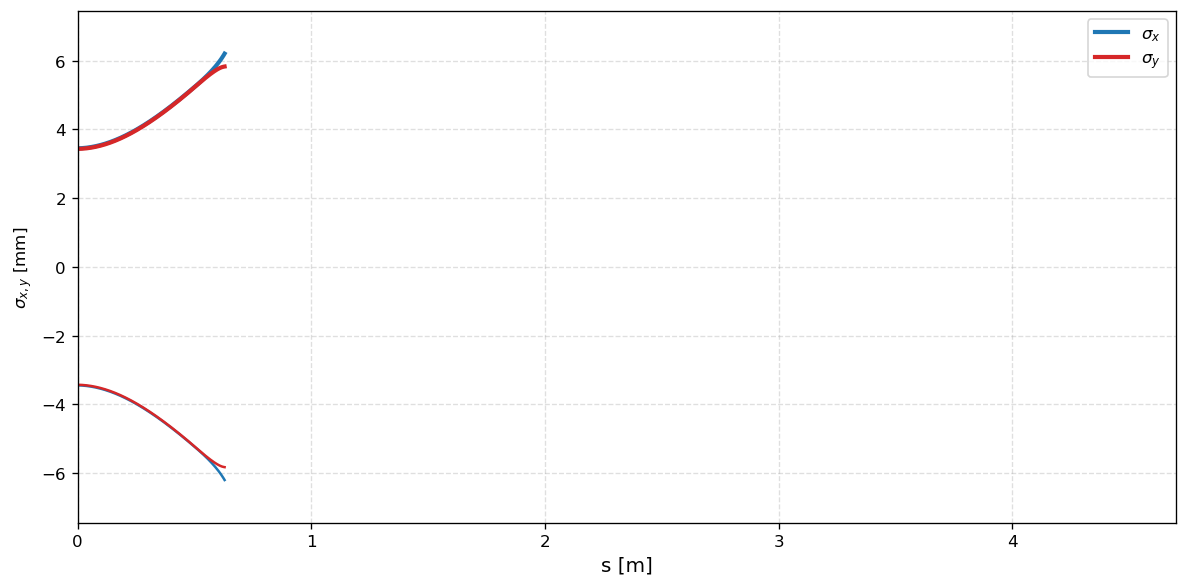

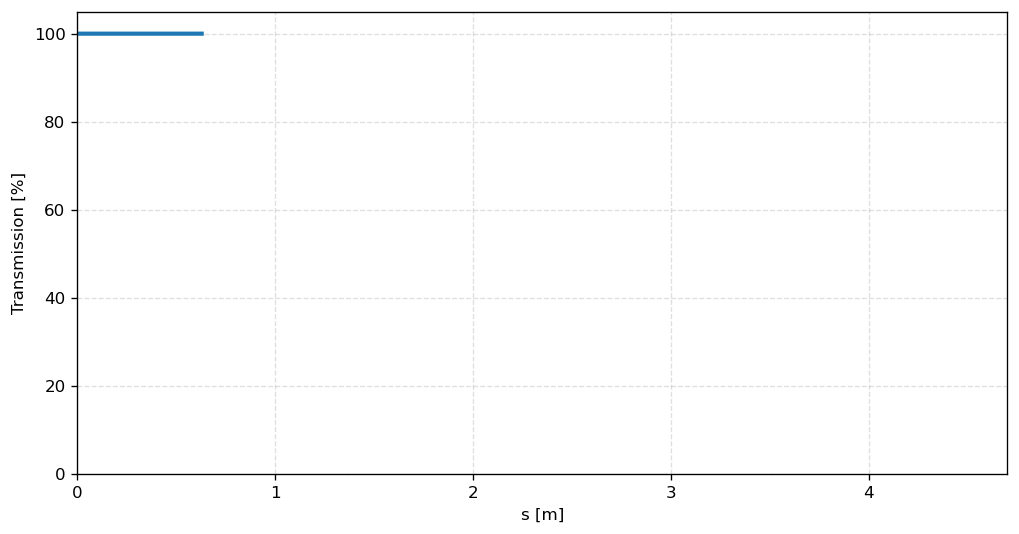

In [ ]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


datos = np.loadtxt("lebt.stat", skiprows=303)

s = datos[:,1]
rms_x = datos[:,5] * 1e3   
rms_y = datos[:,6] * 1e3
N = datos[:,2]

results_dir = Path.cwd().resolve().parent / "beam_plots"
results_dir.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(10, 5), dpi=120)
color_x = 'tab:blue'
color_y = 'tab:red'
ax.plot(s,  rms_x, color=color_x,linewidth=2.5, label=r'$\sigma_x$')
ax.plot(s, -rms_x, color=color_x,linewidth=1.5)
ax.plot(s,  rms_y, color=color_y, linewidth=2.5, label=r'$\sigma_y$')
ax.plot(s, -rms_y, color=color_y, linewidth=1.5)
ax.set_xlabel('s [m]',fontsize=12)
ax.set_ylabel(r'$\sigma_{x,y}$ [mm]')
ax.set_xlim(0, 4.7)
ax.set_ylim(-max(rms_x)*1.2, max(rms_x)*1.2)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
fig.savefig(results_dir / "opal_lebt_lattice.png", bbox_inches="tight")
plt.show()

# transmission plot
plt.figure(figsize=(10, 5), dpi=120)
plt.plot(s, N/N[0]*100, color="tab:red",linewidth=2.5)
plt.xlabel('s [m]')
plt.ylabel('Transmission [%]')
plt.xlim(0, 4.7)
plt.ylim(0, 105)
plt.grid(True, linestyle='--', alpha=0.4)
plt.savefig(results_dir / "opal_lebt_transmission.png", bbox_inches="tight")
plt.show()

